In [124]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [125]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\SZK776 herox.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41236 entries, 0 to 41235
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  41236 non-null  str  
 1   Message  41236 non-null  str  
 2   Status   41236 non-null  str  
dtypes: str(3)
memory usage: 966.6 KB


In [126]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [127]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-09-23 14:26:38.044 Last fuel report fs02:  2026-09-23 14:28:10.011


In [128]:
values_dates_fs01.info()
values_dates_fs02.info()

<class 'pandas.DataFrame'>
RangeIndex: 18626 entries, 0 to 18625
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     18626 non-null  int64
 1   date      18626 non-null  str  
 2   raw data  18626 non-null  str  
dtypes: int64(1), str(2)
memory usage: 436.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 7687 entries, 0 to 7686
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     7687 non-null   int64
 1   date      7687 non-null   str  
 2   raw data  7687 non-null   str  
dtypes: int64(1), str(2)
memory usage: 180.3 KB


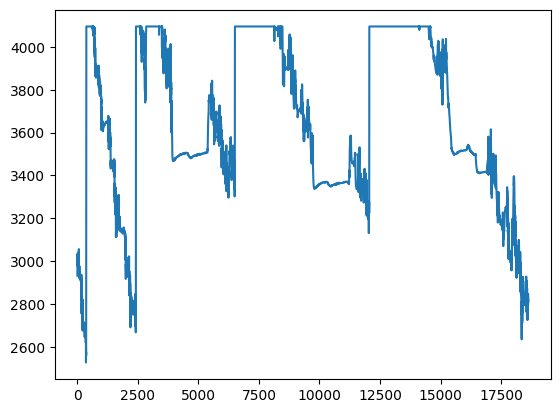

In [129]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [130]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,0])<=4095:
        print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[i,2][32:44],values_dates_fs01_ordered.iloc[i,0])

0 0x2525210020C86A086948706022757526090100002401013E01072E740B4CB7A7 -> 260901000024 2932
1 0x2525210020C86B086948706022757526090100020901013E01072DC90B98BCA6 -> 260901000209 3017
2 0x2525210020C86D086948706022757526090100035401013E01072DC20B29BCF4 -> 260901000354 3010
3 0x2525210020C86E086948706022757526090100053901013E01072FCD0BD5BC39 -> 260901000539 3021
4 0x2525210020C870086948706022757526090100072401013E010730D40B43BDB6 -> 260901000724 3028
5 0x2525210020C871086948706022757526090100090901013E010730DB0BB2BD71 -> 260901000909 3035
6 0x2525210020C873086948706022757526090100105401013E010730DA0BABBDA0 -> 260901001054 3034
7 0x2525210020C874086948706022757526090100123901013E010730DA0BA5BD7C -> 260901001239 3034
8 0x2525210020C875086948706022757526090100142401013E01072FA20B29BA3A -> 260901001424 2978
9 0x2525210020C877086948706022757526090100160901013E010730AE0BE0BA3D -> 260901001609 2990
10 0x2525210020C878086948706022757526090100175401013E010730B10B17BB36 -> 260901001754 2993
11 0x2525

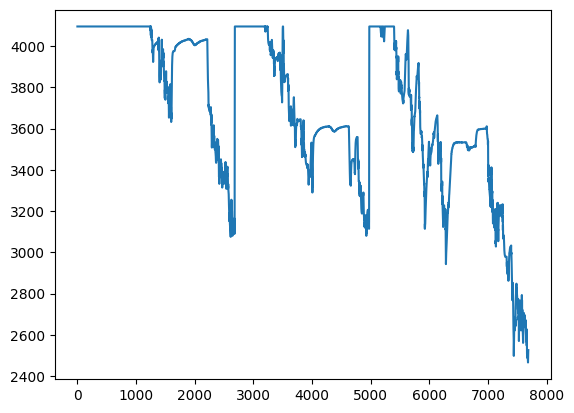

In [131]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [132]:
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,0])<=4095:
        print(i,values_dates_fs02_ordered.iloc[i,2],'->',values_dates_fs02_ordered.iloc[i,2][32:44],values_dates_fs02_ordered.iloc[i,0])

0 0x2525210020C86C086948706022757526090100021601013E020724FF0FFFFF5D -> 260901000216 4095
1 0x2525210020C86F086948706022757526090100063101013E020723FF0FFFFF0C -> 260901000631 4095
2 0x2525210020C872086948706022757526090100104601013E020723FF0FFFFF0C -> 260901001046 4095
3 0x2525210020C876086948706022757526090100150101013E020723FF0FFFFF0C -> 260901001501 4095
4 0x2525210020C879086948706022757526090100191601013E020723FF0FFFFF0C -> 260901001916 4095
5 0x2525210020C87D086948706022757526090100233100013E020722FF0FFFFFC1 -> 260901002331 4095
6 0x2525210020C880086948706022757526090100274600013E020721FF0FFFFF8F -> 260901002746 4095
7 0x2525210020C884086948706022757526090100320100013E020720FF0FFFFF42 -> 260901003201 4095
8 0x2525210020C887086948706022757526090100361600013E020720FF0FFFFF42 -> 260901003616 4095
9 0x2525210020C88A086948706022757526090100403100013E020720FF0FFFFF42 -> 260901004031 4095
10 0x2525210020C88E086948706022757526090100444600013E020720FF0FFFFF42 -> 260901004446 4095
11 0x2525

In [133]:
values_dates_fs01_ordered.info()

<class 'pandas.DataFrame'>
Index: 18626 entries, 0 to 18625
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     18626 non-null  int64
 1   date      18626 non-null  str  
 2   raw data  18626 non-null  str  
dtypes: int64(1), str(2)
memory usage: 582.1 KB


In [134]:
gallons_fs01=[]
gallons_fs02=[]
m1=0.1175
b1=-20.619
m2=0.1175
b2=-20.619

values_dates_fs01_ordered.info()

for i in range(0,values_dates_fs01_ordered.shape[0]):
    gallons_value_fs01=(float(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)
    gallons_fs01.append(gallons_value_fs01) 
    #print(i,values_dates_fs01_ordered.iloc[i,2][32:44],(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)

for i in range(0,values_dates_fs02_ordered.shape[0]):
    gallons_value_fs02=(float(values_dates_fs02_ordered.iloc[i,0]*m2-b2)/3.785412)
    gallons_fs02.append(gallons_value_fs02)  
    #print(i,values_dates_fs02_ordered.iloc[i,2][32:44],(values_dates_fs02_ordered.iloc[i,0]*m1-b1)/3.785412)

values_dates_fs01_ordered['gallons']=gallons_fs01
values_dates_fs02_ordered['gallons']=gallons_fs02

<class 'pandas.DataFrame'>
Index: 18626 entries, 0 to 18625
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     18626 non-null  int64
 1   date      18626 non-null  str  
 2   raw data  18626 non-null  str  
dtypes: int64(1), str(2)
memory usage: 582.1 KB


In [135]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260903100000
date2=260903104000

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta
droping 98.19512380686697 99.6540138827689 -1.4588900759019197
raising 99.77817474029247 98.19512380686697 0.1241608575235773
droping 98.81592809448482 99.77817474029247 -0.8380857882840758
raising 99.00216938077018 98.81592809448482 -0.6518445019987098
droping 98.62968680819945 99.00216938077018 -1.0243270745694417
droping 97.85368144867716 98.62968680819945 -1.8003324340917288
droping 95.99126858582368 97.85368144867716 -3.662745296945218
raising 97.07767608915488 95.99126858582368 -2.576337793614016
droping 97.01559566039312 97.07767608915488 -2.638418222375776
raising 98.1330433781052 97.01559566039312 -1.520970504663694
droping 97.66744016239184 98.1330433781052 -1.9865737203770522
droping 97.54327930486826 97.66744016239184 -2.1107345779006295
raising 97.63639994801093 97.54327930486826 -2.0176139347579607
droping 97.48119887610648 97.63639994801093 -2.172815006662418
droping 97.29495758982114 97.

Adding the validation to delete the value that beongs to ragistger i+1, in this case to delete 38.36 that belongs to 260821130825 4046.

In [136]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260903100000
date2=260903104000
level=0

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
droping 98.19512380686697 99.6540138827689 -1.4588900759019197 -1.4588900759019197
raising 99.77817474029247 98.19512380686697 0.1241608575235773 1.583050933425497
droping 98.81592809448482 99.77817474029247 -0.8380857882840758 -0.9622466458076531
raising 99.00216938077018 98.81592809448482 -0.6518445019987098 0.18624128628536596
droping 98.62968680819945 99.00216938077018 -1.0243270745694417 -0.3724825725707319
droping 97.85368144867716 98.62968680819945 -1.8003324340917288 -0.7760053595222871
droping 95.99126858582368 97.85368144867716 -3.662745296945218 -1.862412862853489
raising 97.07767608915488 95.99126858582368 -2.576337793614016 1.086407503331202
droping 97.01559566039312 97.07767608915488 -2.638418222375776 -0.06208042876176023
raising 98.1330433781052 97.01559566039312 -1.520970504663694 1.117447717712082
droping 97.66744016239184 98.1330433781052 -1.9865737203770522 -0.46560321571335

In [137]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260903100000
date2=260903104000
level=0

delta_aux=[]
x_after=[]
x_=[]

df_report=pd.DataFrame()

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):            
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

df_report['x_']=x_
df_report['x_after']=x_after
df_report['delta']=delta_aux

df_report

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
droping 98.19512380686697 99.6540138827689 -1.4588900759019197 -1.4588900759019197
raising 99.77817474029247 98.19512380686697 0.1241608575235773 1.583050933425497
droping 98.81592809448482 99.77817474029247 -0.8380857882840758 -0.9622466458076531
raising 99.00216938077018 98.81592809448482 -0.6518445019987098 0.18624128628536596
droping 98.62968680819945 99.00216938077018 -1.0243270745694417 -0.3724825725707319
droping 97.85368144867716 98.62968680819945 -1.8003324340917288 -0.7760053595222871
droping 95.99126858582368 97.85368144867716 -3.662745296945218 -1.862412862853489
raising 97.07767608915488 95.99126858582368 -2.576337793614016 1.086407503331202
droping 97.01559566039312 97.07767608915488 -2.638418222375776 -0.06208042876176023
raising 98.1330433781052 97.01559566039312 -1.520970504663694 1.117447717712082
droping 97.66744016239184 98.1330433781052 -1.9865737203770522 -0.46560321571335

,x_,x_after,delta
0,99.654014,98.195124,-1.458890
1,98.195124,99.778175,1.583051
2,99.778175,98.815928,-0.962247
3,98.815928,99.002169,0.186241
4,99.002169,98.629687,-0.372483
5,98.629687,97.853681,-0.776005
6,97.853681,95.991269,-1.862413
7,95.991269,97.077676,1.086408
8,97.077676,97.015596,-0.062080
9,97.015596,98.133043,1.117448
